In [3]:
import os
from architecture import ConvNetPooling, nn
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder, EMNIST
import torchvision.transforms as transforms
import json
import numpy as np
from sklearn.metrics import confusion_matrix
from train import validation

dir_path = os.path.abspath('')

device = torch.device("cuda")
batch_size = 32
to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), transforms.ToTensor()
])
dataset = EMNIST(root="data_emnist", split="letters", train=False, transform=to_tensor)
labels = [label for _, label in dataset]
output_size = len(set(labels))
sample_image, _ = dataset[0]
_, width, height = list(sample_image.shape)
testloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

label_mapping = [chr(ord('a') + i) for i in range(0, 26)]


def load_model(model_path, metadata_path):
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    model = ConvNetPooling(height=height, width=width, output=output_size, channels=metadata['channels'])
    model.load_state_dict(torch.load(model_path, weights_only=True))
    return model


In [5]:
pyramid_model_path = os.path.join(dir_path, 'best_models', 'best_pyramid', 'cnn20.pth')
pyramid_metadata_path = os.path.join(os.path.dirname(pyramid_model_path), 'train_metadata20.json')
pyramid_conv_net = load_model(pyramid_model_path, pyramid_metadata_path)

d = validation(pyramid_conv_net, testloader, save_folder=None)
pyramid_predicted = d['predicted']
pyramid_expected = d['expected']

pyramid_cm = confusion_matrix(pyramid_expected, pyramid_predicted)

c:\Users\mokrota\Documents\GitHub\Neural-Network-Project\.venv\Lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [7]:
reverse_pyramid_model_path = os.path.join(dir_path, 'best_models', 'best_reverse_pyramid', 'cnn10.pth')
reverse_pyramid_metadata_path = os.path.join(os.path.dirname(reverse_pyramid_model_path), 'train_metadata10.json')
reverse_pyramid_conv_net = load_model(reverse_pyramid_model_path, reverse_pyramid_metadata_path)

d = validation(reverse_pyramid_conv_net, testloader, save_folder=None)
reverse_pyramid_predicted = d['predicted']
reverse_pyramid_expected = d['expected']

reverse_pyramid_cm = confusion_matrix(reverse_pyramid_expected, reverse_pyramid_predicted)

c:\Users\mokrota\Documents\GitHub\Neural-Network-Project\.venv\Lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


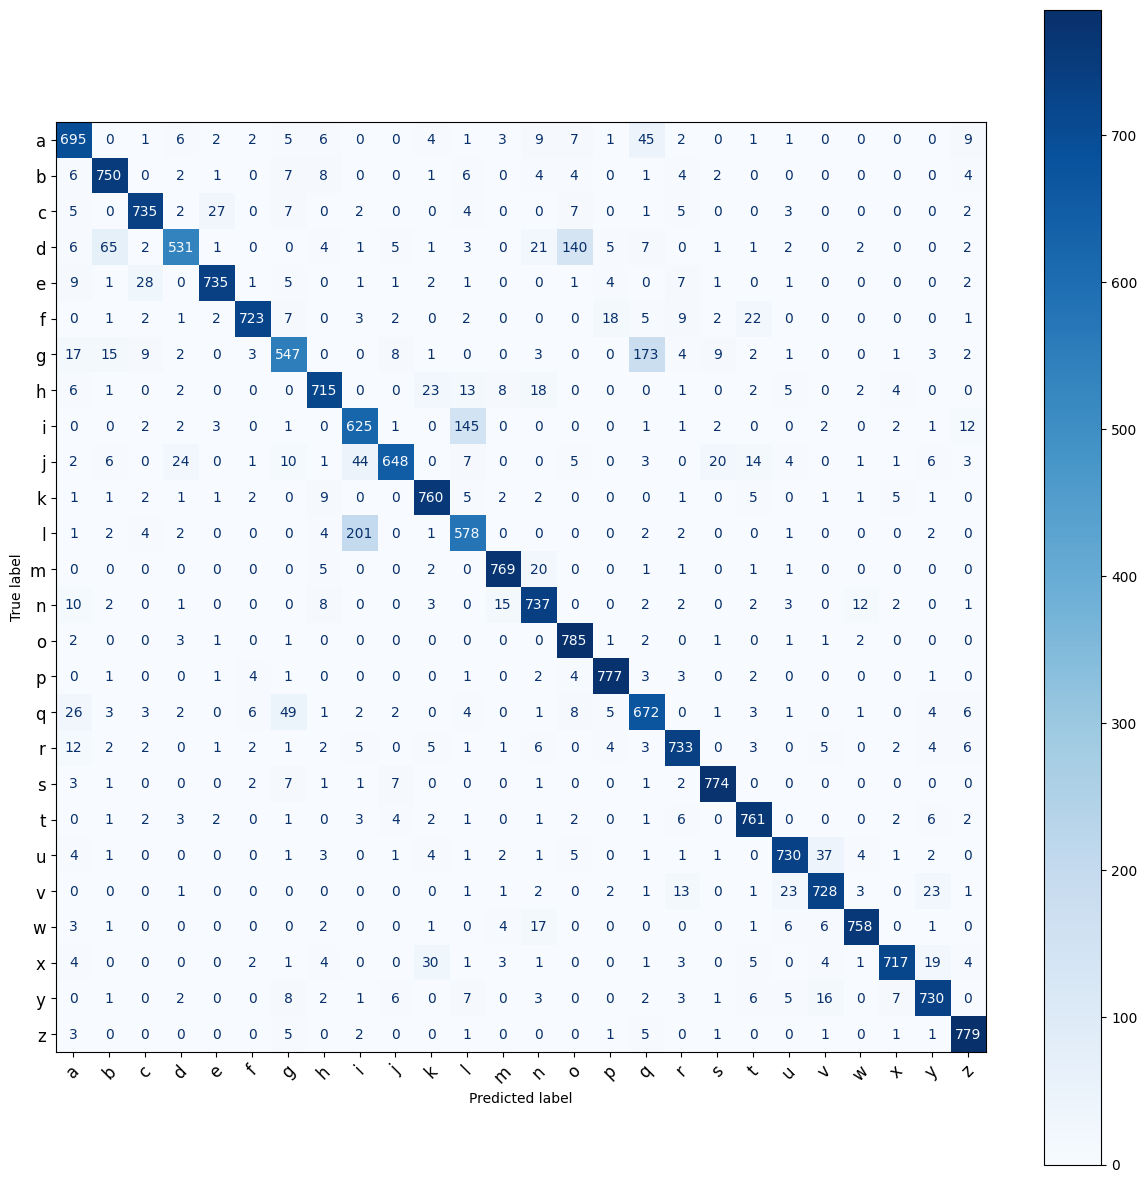

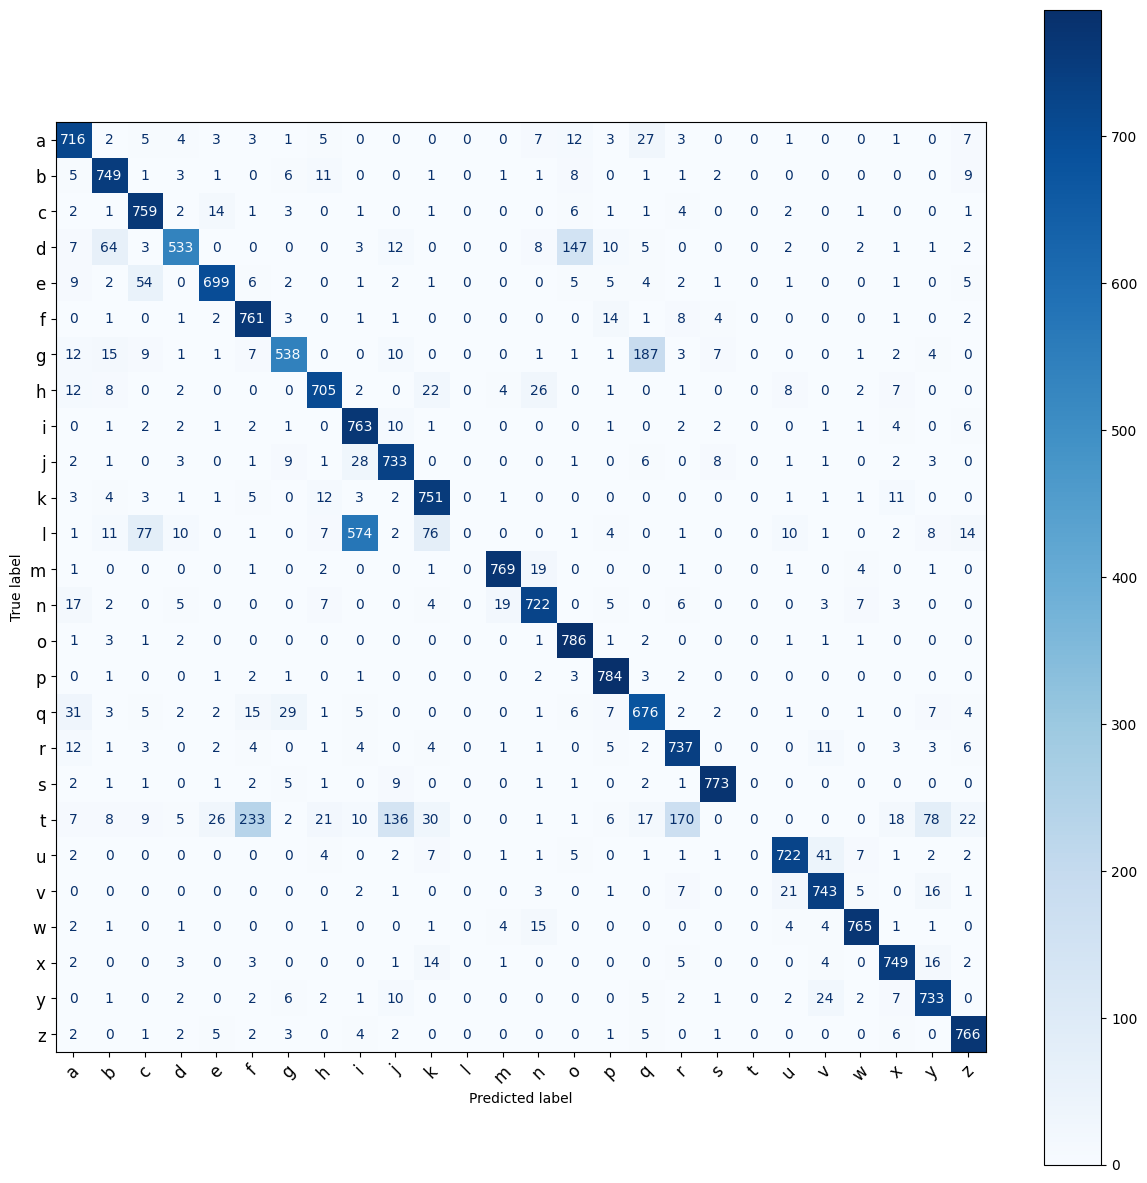

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def show_cm(cm):
    fig, ax = plt.subplots(figsize=(15, 15))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[chr(ord('a') + i) for i in range(26)])
    disp.plot(ax=ax, cmap="Blues", values_format='d')

    plt.xticks(fontsize=12, rotation=45)
    plt.yticks(fontsize=12)

    plt.show()

show_cm(pyramid_cm)
show_cm(reverse_pyramid_cm)

In [11]:
def accuracy(cm):
    correct = cm.diagonal().sum()
    total = cm.sum()
    print(correct / total)

accuracy(pyramid_cm)
accuracy(reverse_pyramid_cm)

0.8890384615384616
0.838076923076923
